# Notebook 9 - Class Weights - Tous modèles - 256×256


In [1]:
# os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
# os.environ["XLA_FLAGS"] = "--xla_gpu_strict_conv_algorithm_picker=false"
# os.environ["TF_XLA_FLAGS"] = "--tf_xla_auto_jit=0"
# os.environ["TF_CUDNN_USE_AUTOTUNE"] = "0"

import os

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

os.environ["TF_USE_CUDNN_AUTOTUNE"] = "0"
os.environ["TF_CUDNN_USE_AUTOTUNE"] = "0"

# "1" si PB.
os.environ["TF_CUDNN_USE_FRONTEND"] = "0"

# Désactive le XLA auto-jit
os.environ["TF_XLA_FLAGS"] = "--tf_xla_auto_jit=0"

In [2]:
import tensorflow as tf

tf.config.optimizer.set_jit(False)
tf.config.experimental.enable_op_determinism()

gpus = tf.config.list_physical_devices("GPU")
print("GPUs:", gpus)

if gpus:
    tf.config.set_logical_device_configuration(
        gpus[0], [tf.config.LogicalDeviceConfiguration(memory_limit=9000)]
    )

print("TF:", tf.__version__)

GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TF: 2.20.0


In [3]:
os.environ["XLA_FLAGS"] = "--xla_gpu_unsafe_fallback_to_driver_on_ptxas_not_found"

import sys, gc, json, time, random, math
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import backend as K
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import confusion_matrix as sk_confusion_matrix
from PIL import Image as PILImage
import albumentations as A

try:
    import keras_hub
    HAS_KERAS_HUB = True
except ImportError:
    HAS_KERAS_HUB = False
    print("keras_hub non disponible")

print(f"Python     : {sys.version.split()[0]}")
print(f"TensorFlow : {tf.__version__}")
print(f"GPU        : {[g.name for g in tf.config.list_physical_devices('GPU')]}")

Python     : 3.12.3
TensorFlow : 2.20.0
GPU        : ['/physical_device:GPU:0']


In [ ]:
ROOT           = Path.home() / "PROJ9"
CITYSCAPES_DIR = ROOT / "data" / "raw" / "cityscapes"
SPLIT_CSV      = next(ROOT.glob("**/*split*.csv"), None)
OUT_DIR        = ROOT / "out" / "experiments"
OUT_DIR.mkdir(parents=True, exist_ok=True)
if SPLIT_CSV is None:
    raise FileNotFoundError(f"Split CSV introuvable dans {ROOT}")

EPOCHS = 40; EPOCHS_FT = 20; PATIENCE = 4; SEED = 42
AUG = True; SIZE_HW = (256, 256); BATCH_SIZE = 4

# 3 modes disponibles :
#   "soft"        : poids doux manuels
#   "median_freq" : poids auto depuis distribution pixel
#   "custom"      : poids 100% manuels
WEIGHT_MODE = "median_freq"

# Poids doux : classes majoritaires a 1.0, classes rares boostees x2-2.5
SOFT_WEIGHTS = {"void": 0.1, "flat": 1.0, "construction": 1.0, "object": 2.0,
                "nature": 1.0, "sky": 1.0, "human": 2.5, "vehicle": 1.0}

# Poids custom
CUSTOM_WEIGHTS = {"void": 0.1, "flat": 0.5, "construction": 0.5, "object": 4.0,
                  "nature": 0.8, "sky": 1.0, "human": 3.5, "vehicle": 1.0}
tf.random.set_seed(SEED); np.random.seed(SEED); random.seed(SEED)

In [ ]:
IGNORE_LABEL = 255; N_CLASSES = 8
CATEGORY_NAMES = ["void","flat","construction","object","nature","sky","human","vehicle"]
PALETTE = np.array([[0,0,0],[128,64,128],[70,70,70],[153,153,153],
                    [107,142,35],[70,130,180],[220,20,60],[0,0,142]], dtype=np.uint8)

REMAP = np.full(256, IGNORE_LABEL, dtype=np.uint8)
for lid in [0,1,2,3,4,5]:                REMAP[lid] = 0  # void
for lid in [6,7,8,9,10]:                 REMAP[lid] = 1  # flat
for lid in [11,12,13,14,15,16]:          REMAP[lid] = 2  # construction
for lid in [17,18,19,20]:                REMAP[lid] = 3  # object
for lid in [21,22]:                      REMAP[lid] = 4  # nature
REMAP[23] = 5                                            # sky
for lid in [24,25]:                      REMAP[lid] = 6  # human
for lid in [26,27,28,29,30,31,32,33]:    REMAP[lid] = 7  # vehicle

print(f"REMAP OK : labelId 5->{REMAP[5]}(void)  6->{REMAP[6]}(flat)  7->{REMAP[7]}(flat)")

REMAP OK : labelId 5->0(void)  6->1(flat)  7->1(flat)


In [6]:
def load_rgb(path): return PILImage.open(str(path)).convert("RGB")

def load_mask(path):
    arr = np.array(PILImage.open(str(path)), dtype=np.uint8)
    return PILImage.fromarray(REMAP[arr])

def resolve(row, base, ca, cr):
    v = row.get(ca, "")
    return v if isinstance(v, str) and v else f"{base}/{row[cr]}"  

## 1. Distribution des classes et calcul des poids


In [7]:
df = pd.read_csv(SPLIT_CSV)
train_df = df[df["split_final"]=="train"].copy()
val_df   = df[df["split_final"]=="val"].copy()
test_df  = df[df["split_final"]=="test"].copy()
print(f"Train:{len(train_df)} | Val:{len(val_df)} | Test:{len(test_df)}")

print("\nComptage pixels par classe (train set)...")
pixel_counts = np.zeros(N_CLASSES, dtype=np.int64)
t0 = time.time()
for idx, row in train_df.iterrows():
    arr = np.array(load_mask(resolve(row, CITYSCAPES_DIR, "mask_path", "mask_rel")), dtype=np.uint8)
    for c_ in range(N_CLASSES):
        pixel_counts[c_] += (arr == c_).sum()
    if idx % 500 == 0: print(f"  {idx}...", end="\r")
print(f"\nTermine en {time.time()-t0:.0f}s")

total_valid = pixel_counts[1:].sum()
frequencies = np.zeros(N_CLASSES, dtype=np.float64)
frequencies[1:] = pixel_counts[1:] / total_valid

if WEIGHT_MODE == "median_freq":
    median_freq = np.median(frequencies[1:])
    with np.errstate(divide="ignore", invalid="ignore"):
        class_weights = np.where(frequencies > 0, median_freq / frequencies, 0.0)
    class_weights[0] = 0.1
    class_weights[1:] = class_weights[1:] / class_weights[1:].mean()
    class_weights = class_weights.astype(np.float32)
elif WEIGHT_MODE == "soft":
    class_weights = np.array([SOFT_WEIGHTS[n] for n in CATEGORY_NAMES], dtype=np.float32)
else:
    class_weights = np.array([CUSTOM_WEIGHTS[n] for n in CATEGORY_NAMES], dtype=np.float32)

print(f"\nMode: {WEIGHT_MODE}")
for i, name in enumerate(CATEGORY_NAMES):
    print(f"  {name:<15} {pixel_counts[i]:>14,}  {frequencies[i]*100:>6.2f}%  w={class_weights[i]:.3f}")

Train:2380 | Val:500 | Test:595

Comptage pixels par classe (train set)...
  2000...
Termine en 42s

Mode: median_freq
  void               452,629,505    0.00%  w=0.100
  flat             2,001,048,482   44.09%  w=0.089
  construction     1,095,804,963   24.14%  w=0.162
  object              87,749,755    1.93%  w=2.021
  nature             747,803,175   16.48%  w=0.237
  sky                177,566,814    3.91%  w=0.999
  human               58,848,462    1.30%  w=3.013
  vehicle            369,770,604    8.15%  w=0.480


## 2. Générateur et augmentations


In [8]:
def make_train_aug():
    return A.Compose([
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(brightness_limit=0.12, contrast_limit=0.12, p=0.3),
        A.HueSaturationValue(hue_shift_limit=6, sat_shift_limit=8, val_shift_limit=8, p=0.2),
        A.GaussianBlur(blur_limit=(3,3), p=0.15),
        A.GaussNoise(p=0.2),
        A.ShiftScaleRotate(shift_limit=0.03, scale_limit=0.08, rotate_limit=5, border_mode=0, p=0.35),
    ])

class CityscapesGen(keras.utils.Sequence):
    def __init__(self, df, base_dir, size_hw, batch_size, augment=None, shuffle=True, seed=42):
        self.df = df.reset_index(drop=True)
        self.base_dir = str(base_dir)
        self.H, self.W = size_hw
        self.batch_size = batch_size
        self.augment = augment
        self.seed = seed
        self.shuffle = shuffle
        self.indices = np.arange(len(self.df))
        if shuffle: np.random.RandomState(seed).shuffle(self.indices)

    def __len__(self): return math.ceil(len(self.df) / self.batch_size)

    def _path(self, row, ca, cr):
        v = row.get(ca, "")
        return v if isinstance(v, str) and v else f"{self.base_dir}/{row[cr]}"

    def __getitem__(self, idx):
        idxs = self.indices[idx*self.batch_size:(idx+1)*self.batch_size]
        imgs, masks = [], []
        for i in idxs:
            row = self.df.iloc[i]
            img = load_rgb(self._path(row, "image_path", "image_rel")).resize((self.W, self.H), PILImage.BILINEAR)
            msk = load_mask(self._path(row, "mask_path", "mask_rel")).resize((self.W, self.H), PILImage.NEAREST)
            i_arr = np.array(img, dtype=np.uint8)
            m_arr = np.array(msk, dtype=np.uint8)
            if self.augment is not None:
                np.random.seed(self.seed + int(i) * 1000)
                out = self.augment(image=i_arr, mask=m_arr)
                i_arr, m_arr = out["image"], out["mask"]
            imgs.append(i_arr.astype(np.float32) / 255.0)
            masks.append(m_arr[..., np.newaxis].astype(np.uint8))
        return np.stack(imgs), np.stack(masks)

    def on_epoch_end(self):
        if self.shuffle: np.random.shuffle(self.indices)

## 3. Métriques et loss


In [ ]:
class MeanIoUArgmax(tf.keras.metrics.Metric):
    def __init__(self, num_classes=N_CLASSES, name="mIoU", **kwargs):
        super().__init__(name=name, **kwargs)
        self.num_classes = num_classes
        self.miou = tf.keras.metrics.MeanIoU(num_classes=num_classes)
    def update_state(self, y_true, y_pred, sample_weight=None):
        yt = tf.cast(tf.squeeze(y_true, axis=-1), tf.int32)
        yp = tf.argmax(y_pred, axis=-1, output_type=tf.int32)
        valid = tf.not_equal(yt, IGNORE_LABEL)
        return self.miou.update_state(tf.boolean_mask(yt, valid), tf.boolean_mask(yp, valid))
    def result(self): return self.miou.result()
    def reset_state(self): self.miou.reset_state()
    def get_config(self): return {"num_classes": self.num_classes, "name": self.name}

def make_loss(weights_np):
    w_tf = tf.constant(weights_np, dtype=tf.float32)
    def seg_loss(y_true, y_pred):
        y_t = tf.cast(tf.squeeze(y_true, -1), tf.int32)
        valid = tf.not_equal(y_t, IGNORE_LABEL)
        y_s = tf.where(valid, y_t, tf.zeros_like(y_t))
        w_map = tf.gather(w_tf, y_s)
        ce = tf.keras.losses.sparse_categorical_crossentropy(y_s, y_pred)
        ce = tf.where(valid, ce * w_map, tf.zeros_like(ce))
        ce_v = tf.reduce_sum(ce) / (tf.reduce_sum(tf.cast(valid, tf.float32)) + 1e-6)
        y_oh = tf.one_hot(y_s, N_CLASSES)
        vf = tf.cast(valid, tf.float32)[..., tf.newaxis]
        ypc = tf.clip_by_value(y_pred, 1e-6, 1.0 - 1e-6)
        inter = tf.reduce_sum(y_oh * vf * ypc * vf, axis=[0, 1, 2])
        denom = tf.reduce_sum(y_oh * vf + ypc * vf, axis=[0, 1, 2])
        dice_per_class = (2.0 * inter + 1e-6) / (denom + 1e-6)
        weighted_dice = tf.reduce_sum(w_tf * dice_per_class) / (tf.reduce_sum(w_tf) + 1e-6)
        dice_loss = 1.0 - weighted_dice
        return ce_v + 0.5 * dice_loss
    return seg_loss

seg_loss = make_loss(class_weights)
print("Loss initialisee.")

Loss initialisee.


I0000 00:00:1773230934.705066 1839287 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9000 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1080 Ti, pci bus id: 0000:07:00.0, compute capability: 6.1


## 4. Architectures


In [ ]:
def conv_block(x, f):
    x = layers.Conv2D(f, 3, padding="same", use_bias=False, kernel_initializer="he_normal")(x)
    x = layers.BatchNormalization()(x); x = layers.ReLU()(x)
    x = layers.Conv2D(f, 3, padding="same", use_bias=False, kernel_initializer="he_normal")(x)
    x = layers.BatchNormalization()(x); return layers.ReLU()(x)

# UNet Scratch
def build_unet_scratch(size_hw, trainable=None):
    inp = layers.Input(shape=(*size_hw, 3))
    c1 = conv_block(inp, 32);  p1 = layers.MaxPooling2D()(c1)
    c2 = conv_block(p1,  64);  p2 = layers.MaxPooling2D()(c2)
    c3 = conv_block(p2, 128);  p3 = layers.MaxPooling2D()(c3)
    c4 = conv_block(p3, 256);  p4 = layers.MaxPooling2D()(c4)
    bn = conv_block(p4, 512)
    def up(x, skip, f):
        x = layers.UpSampling2D()(x); x = layers.Concatenate()([x, skip]); return conv_block(x, f)
    x = up(bn, c4, 256); x = up(x, c3, 128); x = up(x, c2, 64); x = up(x, c1, 32)
    out = layers.Conv2D(N_CLASSES, 1, activation="softmax", padding="same")(x)
    return keras.Model(inp, out, name="unet_scratch")

# UNet VGG16
def build_unet_vgg16(size_hw, trainable=False):
    base = tf.keras.applications.VGG16(include_top=False, weights="imagenet", input_shape=(*size_hw, 3))
    base.trainable = trainable
    s1 = base.get_layer("block1_conv2").output; s2 = base.get_layer("block2_conv2").output
    s3 = base.get_layer("block3_conv3").output; s4 = base.get_layer("block4_conv3").output
    b  = base.get_layer("block5_conv3").output
    def up(x, skip, f):
        x = layers.UpSampling2D()(x); x = layers.Concatenate()([x, skip]); return conv_block(x, f)
    x = up(b, s4, 512); x = up(x, s3, 256); x = up(x, s2, 128); x = up(x, s1, 64)
    out = layers.Conv2D(N_CLASSES, 1, activation="softmax", padding="same")(x)
    return keras.Model(base.input, out, name="unet_vgg16")

# UNet ResNet50
@tf.keras.utils.register_keras_serializable(package="proj9_nb10")
class ResNet50Preprocess(layers.Layer):
    def call(self, inputs): return tf.keras.applications.resnet50.preprocess_input(inputs * 255.0)

def build_unet_resnet50(size_hw, trainable=False):
    inp = layers.Input(shape=(*size_hw, 3), name="image_rgb_01")
    x = ResNet50Preprocess(name="resnet50_preprocess")(inp)
    base = tf.keras.applications.ResNet50(include_top=False, weights="imagenet", input_tensor=x)
    base.trainable = trainable
    s1 = base.get_layer("conv1_relu").output;        s2 = base.get_layer("conv2_block3_out").output
    s3 = base.get_layer("conv3_block4_out").output;   s4 = base.get_layer("conv4_block6_out").output
    b  = base.get_layer("conv5_block3_out").output
    def up(x, skip, f):
        x = layers.UpSampling2D(size=(2,2), interpolation="bilinear")(x)
        x = layers.Concatenate()([x, skip]); return conv_block(x, f)
    x = up(b, s4, 512); x = up(x, s3, 256); x = up(x, s2, 128); x = up(x, s1, 64)
    x = layers.UpSampling2D(size=(2,2), interpolation="bilinear")(x)
    out = layers.Conv2D(N_CLASSES, 1, activation="softmax", padding="same")(x)
    return keras.Model(inp, out, name="unet_resnet50")

# UNet ConvNeXt Tiny
@tf.keras.utils.register_keras_serializable(package="proj9_nb10")
class ConvNeXtPreprocess(layers.Layer):
    def call(self, inputs): return inputs * 255.0

def _pick_by_hw(base_model, wanted_hw):
    picked = {}
    for layer in base_model.layers:
        try: out = layer.output
        except: continue
        if out is None or len(out.shape) != 4: continue
        h, w = int(out.shape[1]), int(out.shape[2])
        if (h, w) in wanted_hw: picked[(h, w)] = out
    return picked

def build_unet_convnext(size_hw, trainable=False):
    H, W = size_hw
    inp  = layers.Input(shape=(H, W, 3), name="image_rgb_01")
    x255 = ConvNeXtPreprocess(name="convnext_preprocess")(inp)
    base = tf.keras.applications.ConvNeXtTiny(
        include_top=False, include_preprocessing=True, weights="imagenet", input_shape=(H, W, 3))
    base.trainable = trainable
    wanted = {(H//4, W//4), (H//8, W//8), (H//16, W//16), (H//32, W//32)}
    picked = _pick_by_hw(base, wanted)
    s2, s3, s4, b = picked[(H//4,W//4)], picked[(H//8,W//8)], picked[(H//16,W//16)], picked[(H//32,W//32)]
    feat_model = tf.keras.Model(base.input, [s2, s3, s4, b], name="convnext_feat")
    s2, s3, s4, b = feat_model(x255)
    def up(t, skip, f):
        t = layers.UpSampling2D((2,2), interpolation="bilinear")(t)
        t = layers.Concatenate()([t, skip]); return conv_block(t, f)
    t = up(b, s4, 512); t = up(t, s3, 256); t = up(t, s2, 128)
    t = layers.UpSampling2D((2,2), interpolation="bilinear")(t); t = conv_block(t, 64)
    t = layers.UpSampling2D((2,2), interpolation="bilinear")(t)
    out = layers.Conv2D(N_CLASSES, 1, activation="softmax", padding="same")(t)
    return keras.Model(inp, out, name="unet_convnext_tiny")

# SegFormer MiT-B0
IMAGENET_MEAN = tf.constant([0.485, 0.456, 0.406], dtype=tf.float32)
IMAGENET_STD  = tf.constant([0.229, 0.224, 0.225], dtype=tf.float32)

@tf.keras.utils.register_keras_serializable(package="proj9_nb10")
class SegFormerPreprocess(layers.Layer):
    def call(self, inputs): return (tf.cast(inputs, tf.float32) - IMAGENET_MEAN) / IMAGENET_STD

def build_segformer(size_hw, trainable=False):
    if not HAS_KERAS_HUB: raise ImportError("keras_hub requis")
    input_shape = (*size_hw, 3)
    encoder = keras_hub.models.MiTBackbone.from_preset("mit_b0_cityscapes_1024", image_shape=input_shape)
    encoder.trainable = bool(trainable)
    backbone  = keras_hub.models.SegFormerBackbone(image_encoder=encoder, projection_filters=256)
    segmenter = keras_hub.models.SegFormerImageSegmenter(backbone=backbone, num_classes=N_CLASSES, preprocessor=None)
    inp = layers.Input(shape=input_shape, name="image_rgb_01")
    x   = SegFormerPreprocess(name="segformer_preprocess")(inp)
    y   = segmenter(x)
    if (y.shape[1] is not None and y.shape[2] is not None and
        (y.shape[1] != size_hw[0] or y.shape[2] != size_hw[1])):
        y = layers.Resizing(size_hw[0], size_hw[1], interpolation="bilinear")(y)
    y = layers.Softmax(axis=-1, name="probs")(y)
    return keras.Model(inp, y, name="segformer_mitb0")

# Registre 
BUILDERS = {"UNET_SCRATCH": build_unet_scratch, "UNET_VGG16": build_unet_vgg16,
            "UNET_RESNET50": build_unet_resnet50, "UNET_CONVNEXT": build_unet_convnext}
if HAS_KERAS_HUB: BUILDERS["SEGFORMER"] = build_segformer

LABELS = {"UNET_SCRATCH":"UNet Scratch", "UNET_VGG16":"UNet VGG16", "UNET_RESNET50":"UNet ResNet50",
          "UNET_CONVNEXT":"UNet ConvNeXt", "SEGFORMER":"SegFormer MiT-B0"}

MODEL_LR    = {"UNET_SCRATCH":1e-3, "UNET_VGG16":1e-3, "UNET_RESNET50":1e-3,
               "UNET_CONVNEXT":1e-3, "SEGFORMER":6e-5}
MODEL_LR_FT = {"UNET_SCRATCH":None, "UNET_VGG16":1e-4, "UNET_RESNET50":1e-4,
               "UNET_CONVNEXT":1e-4, "SEGFORMER":2e-5}

print("Architectures et LR configures.")

Architectures et LR configures.


## 5. Entraînement


In [ ]:
def per_class_iou(model, gen):
    conf = np.zeros((N_CLASSES, N_CLASSES), dtype=np.int64)
    for X_b, y_b in gen:
        preds = np.argmax(model.predict(X_b, verbose=0), axis=-1)
        gt = y_b[..., 0].astype(np.int32); valid = gt != IGNORE_LABEL
        if valid.any():
            conf += sk_confusion_matrix(gt[valid].flatten(), preds[valid].flatten(), labels=list(range(N_CLASSES)))
    iou = []
    for c_ in range(N_CLASSES):
        tp = conf[c_,c_]; fn = conf[c_,:].sum()-tp; fp = conf[:,c_].sum()-tp; d = tp+fn+fp
        iou.append(float(tp)/float(d) if d > 0 else 0.0)
    return iou

def run_model(model_name):
    is_scratch = (model_name == "UNET_SCRATCH")
    lr_ph1 = MODEL_LR[model_name]
    lr_ft  = MODEL_LR_FT.get(model_name)

    aug = make_train_aug() if AUG else None
    train_seq = CityscapesGen(train_df, CITYSCAPES_DIR, SIZE_HW, BATCH_SIZE, augment=aug, shuffle=True, seed=SEED)
    val_seq   = CityscapesGen(val_df,   CITYSCAPES_DIR, SIZE_HW, BATCH_SIZE, augment=None, shuffle=False, seed=SEED)
    test_seq  = CityscapesGen(test_df,  CITYSCAPES_DIR, SIZE_HW, BATCH_SIZE, augment=None, shuffle=False, seed=SEED)

    run_name  = f"{model_name}_256_cw{WEIGHT_MODE}_e{EPOCHS}ft{EPOCHS_FT}_s{SEED}"
    ckpt_path = str(OUT_DIR / f"{run_name}.keras")

    # Phase 1 : encodeur gele
    model = BUILDERS[model_name](SIZE_HW, trainable=False) if not is_scratch else BUILDERS[model_name](SIZE_HW)
    model.compile(optimizer=keras.optimizers.Adam(lr_ph1), loss=seg_loss, metrics=[MeanIoUArgmax(name="mIoU")])

    cb = [ModelCheckpoint(ckpt_path, monitor="val_mIoU", mode="max", save_best_only=True, verbose=0),
          EarlyStopping(monitor="val_mIoU", mode="max", patience=PATIENCE, restore_best_weights=True),
          ReduceLROnPlateau(monitor="val_mIoU", mode="max", patience=3, factor=0.5, min_lr=1e-6)]

    t0 = time.time()
    hist1 = model.fit(train_seq, validation_data=val_seq, epochs=EPOCHS, callbacks=cb, verbose=1)
    t_ph1 = time.time() - t0
    ep_split = len(hist1.history["loss"])
    print(f"  Phase 1 : {t_ph1/60:.1f} min | best val mIoU = {max(hist1.history['val_mIoU']):.4f}")
    history = {k: list(v) for k, v in hist1.history.items()}

    # Phase 2 : fine-tuning
    if not is_scratch and lr_ft is not None:
        del model; K.clear_session(); gc.collect()
        custom_objs = {"MeanIoUArgmax": MeanIoUArgmax, "seg_loss": seg_loss,
                       "ResNet50Preprocess": ResNet50Preprocess,
                       "ConvNeXtPreprocess": ConvNeXtPreprocess,
                       "SegFormerPreprocess": SegFormerPreprocess}
        model = tf.keras.models.load_model(ckpt_path, custom_objects=custom_objs, compile=False)
        def deep_unfreeze(m):
            m.trainable = True
            for layer in m.layers:
                layer.trainable = True
                if hasattr(layer, 'layers'):
                    deep_unfreeze(layer)
        deep_unfreeze(model)
        n_total = sum(p.numpy().size for p in model.trainable_weights) + sum(p.numpy().size for p in model.non_trainable_weights)
        n_train = sum(p.numpy().size for p in model.trainable_weights)
        print(f"  FT: {n_train:,}/{n_total:,} params entrainables ({100*n_train/n_total:.1f}%)")
        model.compile(optimizer=keras.optimizers.Adam(lr_ft), loss=seg_loss, metrics=[MeanIoUArgmax(name="mIoU")])
        cb_ft = [ModelCheckpoint(ckpt_path, monitor="val_mIoU", mode="max", save_best_only=True, verbose=0),
                 EarlyStopping(monitor="val_mIoU", mode="max", patience=PATIENCE, restore_best_weights=True),
                 ReduceLROnPlateau(monitor="val_mIoU", mode="max", patience=4, factor=0.5, min_lr=1e-6)]
        t0_ft = time.time()
        hist2 = model.fit(train_seq, validation_data=val_seq, epochs=EPOCHS_FT, callbacks=cb_ft, verbose=1)
        t_ph2 = time.time() - t0_ft
        print(f"  Phase 2 : {t_ph2/60:.1f} min | best val mIoU = {max(hist2.history['val_mIoU']):.4f}")
        for k, v in hist2.history.items():
            history[k] = history.get(k, []) + list(v)
    else:
        t_ph2 = 0

    t_tot = t_ph1 + t_ph2
    if not is_scratch:
        custom_objs = {"MeanIoUArgmax": MeanIoUArgmax, "seg_loss": seg_loss,
                       "ResNet50Preprocess": ResNet50Preprocess,
                       "ConvNeXtPreprocess": ConvNeXtPreprocess,
                       "SegFormerPreprocess": SegFormerPreprocess}
        model = tf.keras.models.load_model(ckpt_path, custom_objects=custom_objs, compile=False)
        model.compile(optimizer=keras.optimizers.Adam(1e-4), loss=seg_loss, metrics=[MeanIoUArgmax(name="mIoU")])
    val_r  = model.evaluate(val_seq, verbose=0)
    test_r = model.evaluate(test_seq, verbose=0)
    iou    = per_class_iou(model, test_seq)

    res = {"run_name": run_name, "model": model_name, "weight_mode": WEIGHT_MODE,
           "class_weights": {CATEGORY_NAMES[i]: round(float(class_weights[i]), 4) for i in range(N_CLASSES)},
           "resolution": 256, "ep_split": ep_split, "epochs_total": len(history["loss"]),
           "train_time_min": round(t_tot / 60, 1),
           "val_loss": round(float(val_r[0]), 4), "val_mIoU": round(float(val_r[1]), 4),
           "test_loss": round(float(test_r[0]), 4), "test_mIoU": round(float(test_r[1]), 4),
           "per_class_iou": {CATEGORY_NAMES[i]: round(iou[i], 4) for i in range(N_CLASSES)},
           "history": {k: [float(v) for v in vals] for k, vals in history.items()}}
    (OUT_DIR / f"{run_name}_results.json").write_text(json.dumps(res, indent=2))
    return res

In [12]:
results = {}
for mname in list(BUILDERS.keys()):
    print(f"\n{'='*60}")
    print(f"  {LABELS.get(mname, mname)} - 256x256 - class weights [{WEIGHT_MODE}]")
    print(f"  LR Ph1={MODEL_LR[mname]} | LR FT={MODEL_LR_FT.get(mname)}")
    print(f"{'='*60}")
    K.clear_session(); gc.collect()
    try:
        results[mname] = run_model(mname)
    except Exception as e:
        import traceback; traceback.print_exc()
        print(f"  [ERREUR] {e}")


  UNet Scratch - 256x256 - class weights [median_freq]
  LR Ph1=0.001 | LR FT=None


/home/ui/PROJ9/.env0/lib/python3.12/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/home/ui/PROJ9/.env0/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/40
595/595 ━━━━━━━━━━━━━━━━━━━━ 309s 501ms/step - loss: 0.6749 - mIoU: 0.3821 - val_loss: 0.6619 - val_mIoU: 0.4229 - learning_rate: 0.0010
Epoch 2/40
595/595 ━━━━━━━━━━━━━━━━━━━━ 298s 500ms/step - loss: 0.5841 - mIoU: 0.4726 - val_loss: 0.5606 - val_mIoU: 0.5160 - learning_rate: 0.0010
Epoch 3/40
595/595 ━━━━━━━━━━━━━━━━━━━━ 298s 501ms/step - loss: 0.5446 - mIoU: 0.5102 - val_loss: 0.5393 - val_mIoU: 0.5533 - learning_rate: 0.0010
Epoch 4/40
595/595 ━━━━━━━━━━━━━━━━━━━━ 297s 499ms/step - loss: 0.5202 - mIoU: 0.5338 - val_loss: 0.5076 - val_mIoU: 0.5608 - learning_rate: 0.0010
Epoch 5/40
595/595 ━━━━━━━━━━━━━━━━━━━━ 299s 503ms/step - loss: 0.4945 - mIoU: 0.5549 - val_loss: 0.4813 - val_mIoU: 0.5845 - learning_rate: 0.0010
Epoch 6/40
595/595 ━━━━━━━━━━━━━━━━━━━━ 298s 501ms/step - loss: 0.4856 - mIoU: 0.5639 - val_loss: 0.4774 - val_mIoU: 0.6018 - learning_rate: 0.0010
Epoch 7/40
595/595 ━━━━━━━━━━━━━━━━━━━━ 297s 498ms/step - loss: 0.4683 - mIoU: 0.5800 - val_loss: 0.5231 - val_m

2026-03-11 16:32:59.648865: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
2026-03-11 16:33:04.831150: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),


  UNet VGG16 - 256x256 - class weights [median_freq]
  LR Ph1=0.001 | LR FT=0.0001


...

E0000 00:00:1773286256.437858 1839287 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/segformer_mitb0_1/seg_former_image_segmenter_1/dropout_16_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


  1/595 ━━━━━━━━━━━━━━━━━━━━ 4:42:04 28s/step - loss: 0.4361 - mIoU: 0.5522

W0000 00:00:1773286259.525845 1839504 conv_ops_gpu.cc:328] None of the algorithms provided by cuDNN frontend heuristics worked; trying fallback algorithms.  Conv: batch: 4
in_depths: 64
out_depths: 160
in: 34
in: 34
data_format: 1
filter: 3
filter: 3
filter: 64
dilation: 1
dilation: 1
stride: 2
stride: 2
padding: 0
padding: 0
dtype: DT_FLOAT
group_count: 1
device_identifier: "sm_6.1 with 11811028992B RAM, 28 cores, 1721000KHz clock, 5505000KHz mem clock, 2883584B L2$"
version: 3



595/595 ━━━━━━━━━━━━━━━━━━━━ 377s 587ms/step - loss: 0.4502 - mIoU: 0.5874 - val_loss: 0.4007 - val_mIoU: 0.6390 - learning_rate: 2.0000e-05
Epoch 2/20
595/595 ━━━━━━━━━━━━━━━━━━━━ 350s 589ms/step - loss: 0.4270 - mIoU: 0.6075 - val_loss: 0.3938 - val_mIoU: 0.6472 - learning_rate: 2.0000e-05
Epoch 3/20
595/595 ━━━━━━━━━━━━━━━━━━━━ 350s 589ms/step - loss: 0.4220 - mIoU: 0.6136 - val_loss: 0.3939 - val_mIoU: 0.6419 - learning_rate: 2.0000e-05
Epoch 4/20
595/595 ━━━━━━━━━━━━━━━━━━━━ 353s 593ms/step - loss: 0.4132 - mIoU: 0.6196 - val_loss: 0.3888 - val_mIoU: 0.6603 - learning_rate: 2.0000e-05
Epoch 5/20
595/595 ━━━━━━━━━━━━━━━━━━━━ 349s 587ms/step - loss: 0.4119 - mIoU: 0.6213 - val_loss: 0.3853 - val_mIoU: 0.6564 - learning_rate: 2.0000e-05
Epoch 6/20
595/595 ━━━━━━━━━━━━━━━━━━━━ 350s 588ms/step - loss: 0.4020 - mIoU: 0.6318 - val_loss: 0.3856 - val_mIoU: 0.6565 - learning_rate: 2.0000e-05
Epoch 7/20
595/595 ━━━━━━━━━━━━━━━━━━━━ 349s 587ms/step - loss: 0.3975 - mIoU: 0.6337 - val_loss: 0

2026-03-12 06:29:38.245183: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
2026-03-12 06:29:43.386876: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

## 6. Résultats


In [13]:
rows = []
for m, r in results.items():
    row = {"Modele": LABELS.get(m, m), "val loss": r["val_loss"],
           "val mIoU": r["val_mIoU"], "test mIoU": r["test_mIoU"]}
    for cls in CATEGORY_NAMES: row[cls] = r["per_class_iou"][cls]
    row["duree (min)"] = r["train_time_min"]
    rows.append(row)
df_res = pd.DataFrame(rows).sort_values("val mIoU", ascending=False).reset_index(drop=True)
float_cols = [c for c in df_res.columns if c not in ["Modele", "duree (min)"]]
display(df_res.style
    .format({c: "{:.4f}" for c in float_cols})
    .format({"duree (min)": "{:.1f}"})
    .background_gradient(subset=["val mIoU", "test mIoU"], cmap="RdYlGn")
    .background_gradient(subset=["human", "object"], cmap="Blues")
    .set_caption(f"Resultats - class weights [{WEIGHT_MODE}] - 256x256"))

,Modele,val loss,val mIoU,test mIoU,void,flat,construction,object,nature,sky,human,vehicle,duree (min)
0,UNet ConvNeXt,0.299200,0.751400,0.766400,0.758800,0.959400,0.818400,0.369900,0.832600,0.901800,0.653600,0.836600,206.5
1,UNet Scratch,0.320000,0.734000,0.753700,0.757400,0.954100,0.792400,0.348500,0.826100,0.907200,0.629700,0.814500,202.5
2,UNet ResNet50,0.347600,0.722500,0.740100,0.746000,0.952600,0.789200,0.301900,0.819000,0.906300,0.595700,0.810400,266.5
3,UNet VGG16,0.348000,0.710700,0.732900,0.738500,0.949600,0.779300,0.310200,0.811000,0.903400,0.578500,0.792700,153.8
4,SegFormer MiT-B0,0.372000,0.672500,0.686800,0.607400,0.933100,0.762000,0.233000,0.798200,0.859000,0.522000,0.780000,198.3


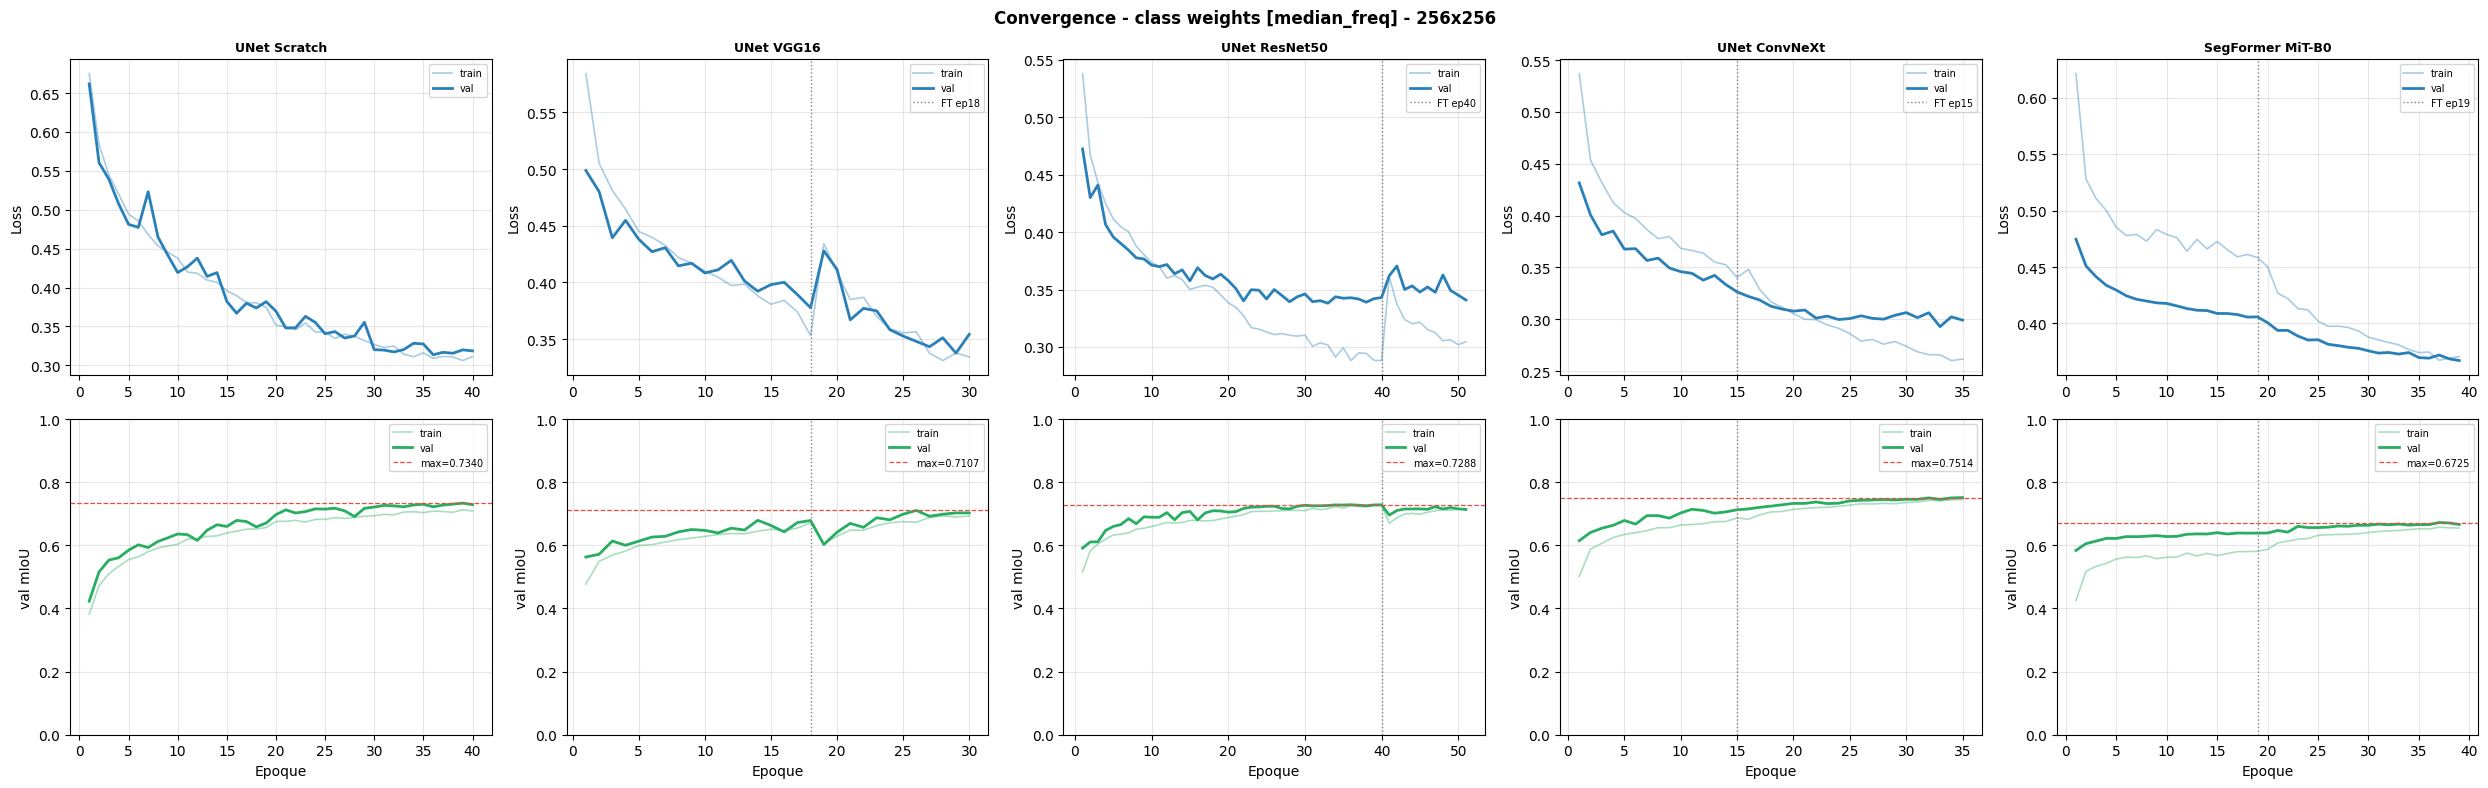

In [14]:
n = len(results)
fig, axes = plt.subplots(2, max(n,1), figsize=(5*max(n,1), 8))
if n == 1: axes = axes.reshape(2, 1)
for j, (mname, r) in enumerate(results.items()):
    hist = r["history"]; ep = range(1, len(hist["val_mIoU"]) + 1); sp = r["ep_split"]
    ax = axes[0][j]
    ax.plot(ep, hist.get("loss",[]), color="#2980b9", alpha=0.4, lw=1.2, label="train")
    ax.plot(ep, hist.get("val_loss",[]), color="#2980b9", lw=2, label="val")
    if 0 < sp < len(list(ep)): ax.axvline(sp, color="grey", linestyle=":", lw=1, label=f"FT ep{sp}")
    ax.set_title(LABELS.get(mname, mname), fontsize=9, fontweight="bold")
    ax.set_ylabel("Loss"); ax.grid(alpha=0.3); ax.legend(fontsize=7)
    ax = axes[1][j]
    ax.plot(ep, hist.get("mIoU",[]), color="#27ae60", alpha=0.4, lw=1.2, label="train")
    ax.plot(ep, hist.get("val_mIoU",[]), color="#27ae60", lw=2, label="val")
    if 0 < sp < len(list(ep)): ax.axvline(sp, color="grey", linestyle=":", lw=1)
    best = max(hist["val_mIoU"])
    ax.axhline(best, color="#e74c3c", linestyle="--", lw=0.9, label=f"max={best:.4f}")
    ax.set_ylim(0, 1); ax.set_ylabel("val mIoU"); ax.grid(alpha=0.3); ax.legend(fontsize=7)
    ax.set_xlabel("Epoque")
plt.suptitle(f"Convergence - class weights [{WEIGHT_MODE}] - 256x256", fontweight="bold")
plt.tight_layout()
plt.savefig(str(OUT_DIR / "classweights_convergence.png"), dpi=130, bbox_inches="tight")
plt.show()

In [15]:
summary = {"weight_mode": WEIGHT_MODE,
    "class_weights": {CATEGORY_NAMES[i]: round(float(class_weights[i]), 4) for i in range(N_CLASSES)},
    "pixel_freq": {CATEGORY_NAMES[i]: round(float(frequencies[i]), 6) for i in range(N_CLASSES)},
    "results": {m: {"val_loss": r["val_loss"], "val_mIoU": r["val_mIoU"], "test_mIoU": r["test_mIoU"],
        "per_class_iou": r["per_class_iou"], "train_time_min": r["train_time_min"]}
        for m, r in results.items()}}
(OUT_DIR / "classweights_summary.json").write_text(json.dumps(summary, indent=2, ensure_ascii=False))
print("Resultats sauvegardes.")

Resultats sauvegardes.
